# Inspección de Archivos CSV
Este notebook recorre la carpeta `archivos_por_columnas` y muestra información detallada de cada archivo:
- Nombre del archivo
- Columnas
- Primeros 5 registros
- Últimos 5 registros
- Cantidad total de registros

In [11]:
import pandas as pd
import os

# Diccionario de descripciones de columnas
column_descriptions = {
    # Identificadores y Tiempo
    'timestamp_unix': 'Fecha y hora del registro (convertido a formato legible)',
    'timestamp_iso': 'Fecha y hora en formato estándar ISO 8601',
    'participant_full_id': 'Identificador único del participante',
    'missing_value_reason': 'Razón por la cual falta el valor (si aplica)',
    # Acelerometría y Movimiento
    'accelerometers_std_g': 'Desviación estándar de la aceleración (vibración/movimiento)',
    'acticounts_x_axis': 'Conteo de actividad "Acticounts" eje X (Algoritmo específico, escala menor)',
    'acticounts_y_axis': 'Conteo de actividad "Acticounts" eje Y (Algoritmo específico, escala menor)',
    'acticounts_z_axis': 'Conteo de actividad "Acticounts" eje Z (Algoritmo específico, escala menor)',
    'counts_x_axis': 'Conteo de Actigrafía estándar eje X (Raw counts/ActiGraph)',
    'counts_y_axis': 'Conteo de Actigrafía estándar eje Y (Raw counts/ActiGraph)',
    'counts_z_axis': 'Conteo de Actigrafía estándar eje Z (Raw counts/ActiGraph)',
    'vector_magnitude': 'Magnitud del Vector (Suma vectorial de X, Y, Z)',
    'step_counts': 'Cantidad de pasos detectados',
    'activity_counts': 'Conteo general de actividad (suma o métrica global)',
    # Clasificación de Actividad y Posición
    'activity_class': 'Clasificación del tipo de actividad (ej. caminar, correr, reposo)',
    'activity_intensity': 'Intensidad de la actividad (sedentario, ligero, moderado, vigoroso)',
    'body_position_left': 'Indicador de posición del cuerpo (Lado Izquierdo)',
    'body_position_right': 'Indicador de posición del cuerpo (Lado Derecho)',
    # Nota: A veces body_position viene como una sola columna o separada.
    # Fisiología
    'eda_scl_usiemens': 'Conductancia de la piel (EDA) en microsiemens (Nivel de estrés/excitación)',
    'met': 'Equivalentes Metabólicos de Tarea (Gasto energético: 1 MET = reposo)',
    'prv_rmssd_ms': 'Variabilidad de la frecuencia del pulso (RMSSD) en ms (Indicador de recuperación/estrés)',
    'pulse_rate_bpm': 'Frecuencia cardíaca (latidos por minuto)',
    'respiratory_rate_brpm': 'Frecuencia respiratoria (respiraciones por minuto)',
    'temperature_celsius': 'Temperatura registrada (°C)',
    # Sueño y Uso
    'sleep_detection_stage': 'Fase de sueño detectada (Despierto, Ligero, Profundo, REM)',
    'wearing_detection_percentage': 'Probabilidad/Porcentaje de que el dispositivo esté en uso (On-wrist)'
}

# Definir la carpeta con los archivos (ahora es el directorio actual)
folder_path = '.'

# Obtener lista de archivos CSV
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(f"Se encontraron {len(files)} archivos en '{folder_path}'.")

for file in files:
    file_path = os.path.join(folder_path, file)
    try:
        # Leer CSV con separador de coma o punto y coma
        try:
            df = pd.read_csv(file_path, sep=';')
            if df.shape[1] == 1:
                # Si solo hay una columna, probablemente el separador es coma
                df = pd.read_csv(file_path, sep=',')
        except Exception:
            df = pd.read_csv(file_path, sep=',')
        
        print(f"--- Archivo: {file} ---")
        print(f"Total de registros: {len(df)}")
        print(f"Columnas: {list(df.columns)}")
        
        print("\nDescripción de columnas:")
        for col in df.columns:
            # Buscar descripción exacta o parcial
            desc = column_descriptions.get(col, "Sin descripción disponible")
            print(f"  - {col}: {desc}")
        
        print("\nPrimeros 5 registros:")
        display(df.head())
        
        print("\nÚltimos 5 registros:")
        display(df.tail())
        
        print("\n" + "="*80 + "\n")
        
    except Exception as e:
        print(f"Error leyendo {file}: {e}")

Se encontraron 16 archivos en '.'.
--- Archivo: 1-1-00_2025-07-28_accelerometers-std.csv ---
Total de registros: 1440
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'accelerometers_std_g', 'missing_value_reason']

Descripción de columnas:
  - timestamp_unix: Fecha y hora del registro (convertido a formato legible)
  - timestamp_iso: Fecha y hora en formato estándar ISO 8601
  - participant_full_id: Identificador único del participante
  - accelerometers_std_g: Desviación estándar de la aceleración (vibración/movimiento)
  - missing_value_reason: Razón por la cual falta el valor (si aplica)

Primeros 5 registros:


,timestamp_unix,timestamp_iso,participant_full_id,accelerometers_std_g,missing_value_reason
0,1753660800000,2025-07-28T00:00:00Z,2100-1-1-00,0.001,NaN
1,1753660860000,2025-07-28T00:01:00Z,2100-1-1-00,0.001,NaN
2,1753660920000,2025-07-28T00:02:00Z,2100-1-1-00,0.001,NaN
3,1753660980000,2025-07-28T00:03:00Z,2100-1-1-00,0.001,NaN
4,1753661040000,2025-07-28T00:04:00Z,2100-1-1-00,0.001,NaN



Últimos 5 registros:


,timestamp_unix,timestamp_iso,participant_full_id,accelerometers_std_g,missing_value_reason
1435,1753746900000,2025-07-28T23:55:00Z,2100-1-1-00,0.026,NaN
1436,1753746960000,2025-07-28T23:56:00Z,2100-1-1-00,0.008,NaN
1437,1753747020000,2025-07-28T23:57:00Z,2100-1-1-00,0.003,NaN
1438,1753747080000,2025-07-28T23:58:00Z,2100-1-1-00,0.008,NaN
1439,1753747140000,2025-07-28T23:59:00Z,2100-1-1-00,0.015,NaN




--- Archivo: 1-1-00_2025-07-28_acticounts.csv ---
Total de registros: 1440
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'acticounts_x_axis', 'acticounts_y_axis', 'acticounts_z_axis', 'missing_value_reason']

Descripción de columnas:
  - timestamp_unix: Fecha y hora del registro (convertido a formato legible)
  - timestamp_iso: Fecha y hora en formato estándar ISO 8601
  - participant_full_id: Identificador único del participante
  - acticounts_x_axis: Conteo de actividad "Acticounts" eje X (Algoritmo específico, escala menor)
  - acticounts_y_axis: Conteo de actividad "Acticounts" eje Y (Algoritmo específico, escala menor)
  - acticounts_z_axis: Conteo de actividad "Acticounts" eje Z (Algoritmo específico, escala menor)
  - missing_value_reason: Razón por la cual falta el valor (si aplica)

Primeros 5 registros:


...

,timestamp_unix,timestamp_iso,participant_full_id,temperature_celsius,missing_value_reason
1435,1753746900000,2025-07-28T23:55:00Z,2100-1-1-00,34.45,NaN
1436,1753746960000,2025-07-28T23:56:00Z,2100-1-1-00,34.41,NaN
1437,1753747020000,2025-07-28T23:57:00Z,2100-1-1-00,34.36,NaN
1438,1753747080000,2025-07-28T23:58:00Z,2100-1-1-00,34.20,NaN
1439,1753747140000,2025-07-28T23:59:00Z,2100-1-1-00,34.19,NaN




--- Archivo: 1-1-00_2025-07-28_wearing-detection.csv ---
Total de registros: 1440
Columnas: ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'wearing_detection_percentage', 'missing_value_reason']

Descripción de columnas:
  - timestamp_unix: Fecha y hora del registro (convertido a formato legible)
  - timestamp_iso: Fecha y hora en formato estándar ISO 8601
  - participant_full_id: Identificador único del participante
  - wearing_detection_percentage: Probabilidad/Porcentaje de que el dispositivo esté en uso (On-wrist)
  - missing_value_reason: Razón por la cual falta el valor (si aplica)

Primeros 5 registros:


,timestamp_unix,timestamp_iso,participant_full_id,wearing_detection_percentage,missing_value_reason
0,1753660800000,2025-07-28T00:00:00Z,2100-1-1-00,100.0,NaN
1,1753660860000,2025-07-28T00:01:00Z,2100-1-1-00,100.0,NaN
2,1753660920000,2025-07-28T00:02:00Z,2100-1-1-00,100.0,NaN
3,1753660980000,2025-07-28T00:03:00Z,2100-1-1-00,100.0,NaN
4,1753661040000,2025-07-28T00:04:00Z,2100-1-1-00,100.0,NaN



Últimos 5 registros:


,timestamp_unix,timestamp_iso,participant_full_id,wearing_detection_percentage,missing_value_reason
1435,1753746900000,2025-07-28T23:55:00Z,2100-1-1-00,100.0,NaN
1436,1753746960000,2025-07-28T23:56:00Z,2100-1-1-00,100.0,NaN
1437,1753747020000,2025-07-28T23:57:00Z,2100-1-1-00,100.0,NaN
1438,1753747080000,2025-07-28T23:58:00Z,2100-1-1-00,100.0,NaN
1439,1753747140000,2025-07-28T23:59:00Z,2100-1-1-00,100.0,NaN


Generando gráficos temporales para 16 archivos...



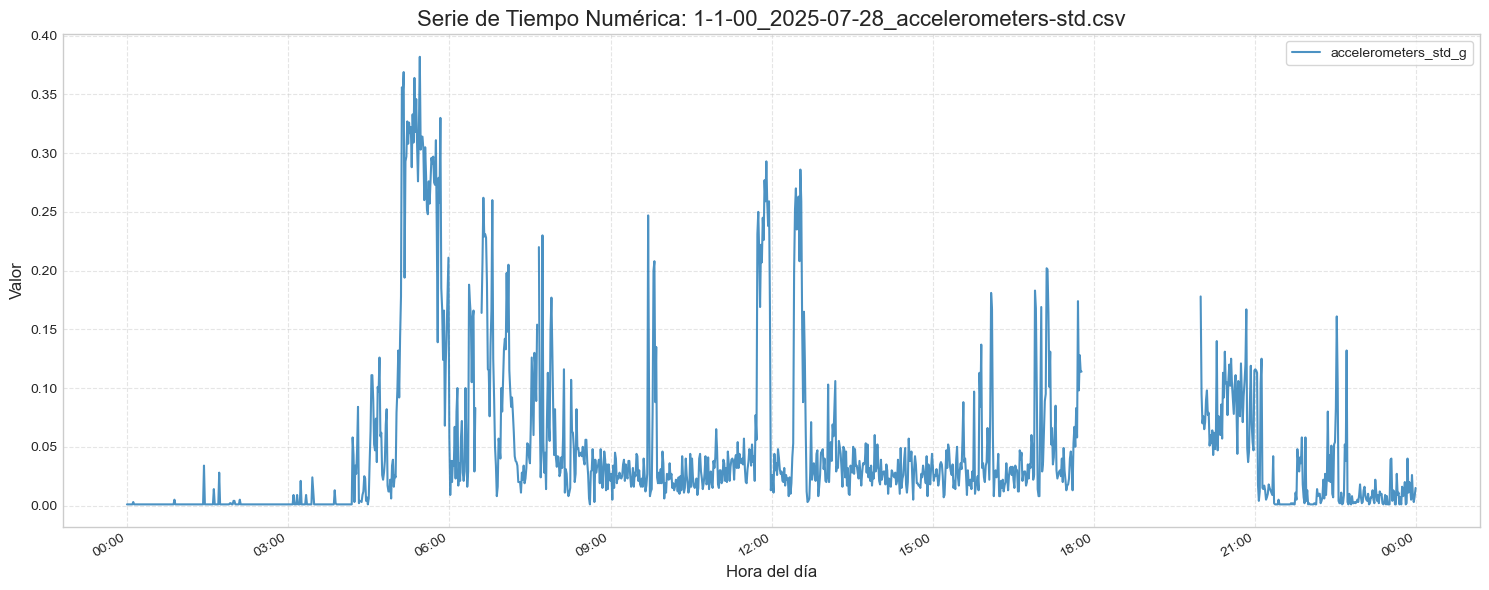


--------------------------------------------------------------------------------



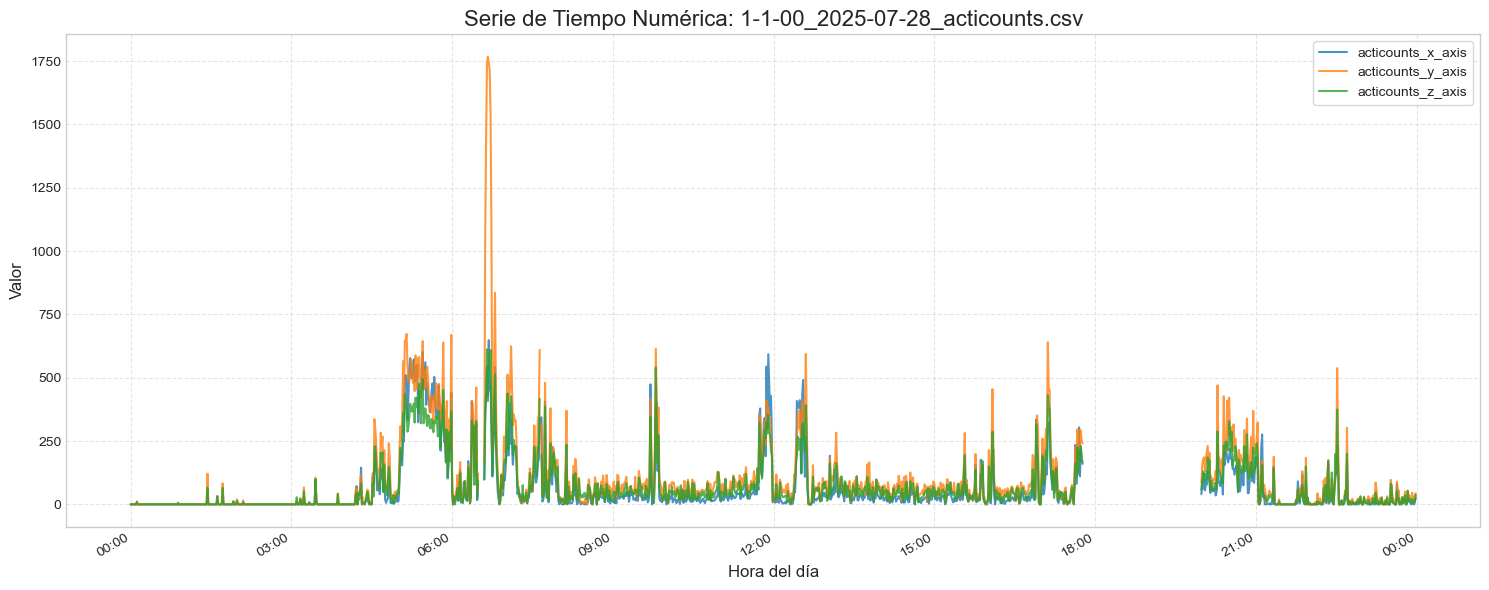


--------------------------------------------------------------------------------



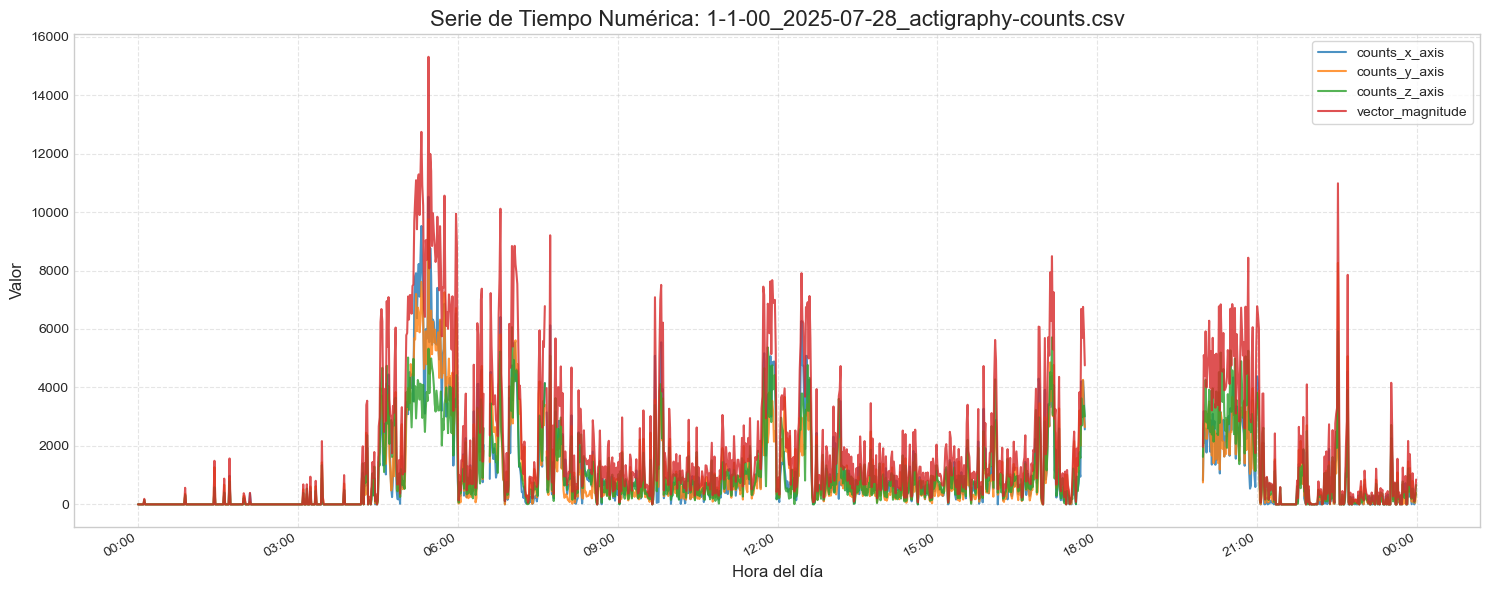


--------------------------------------------------------------------------------



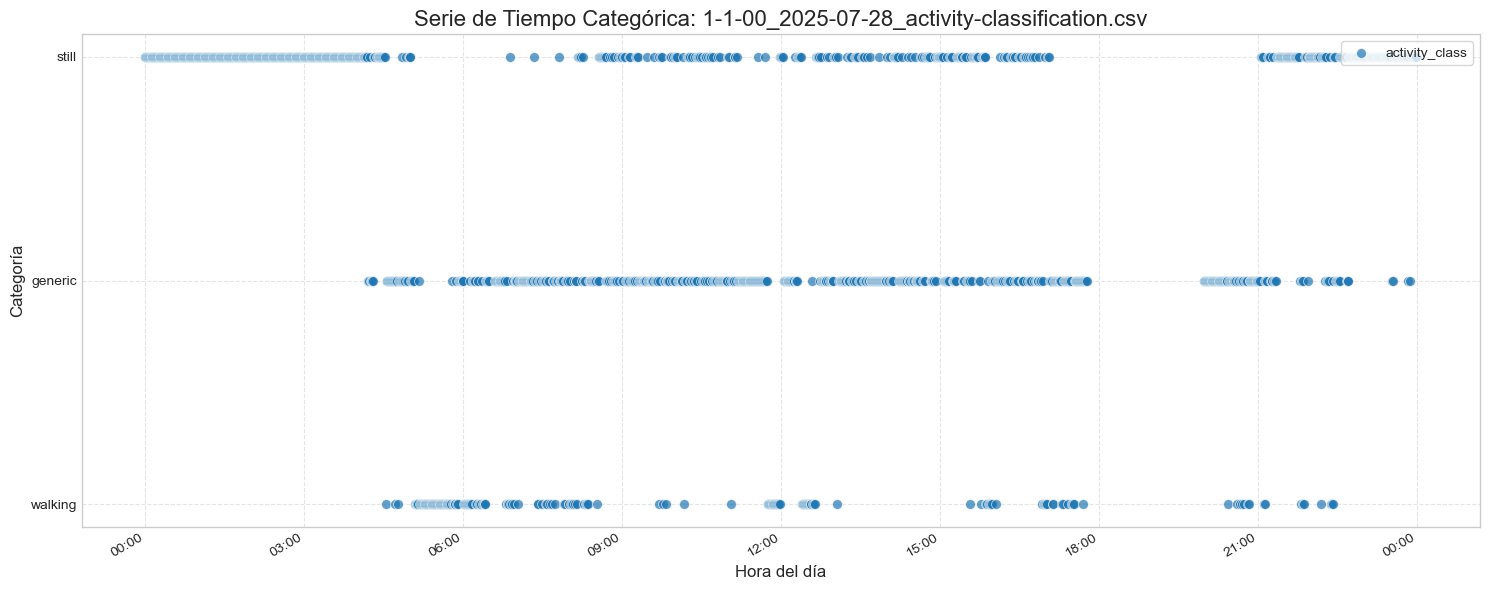


--------------------------------------------------------------------------------



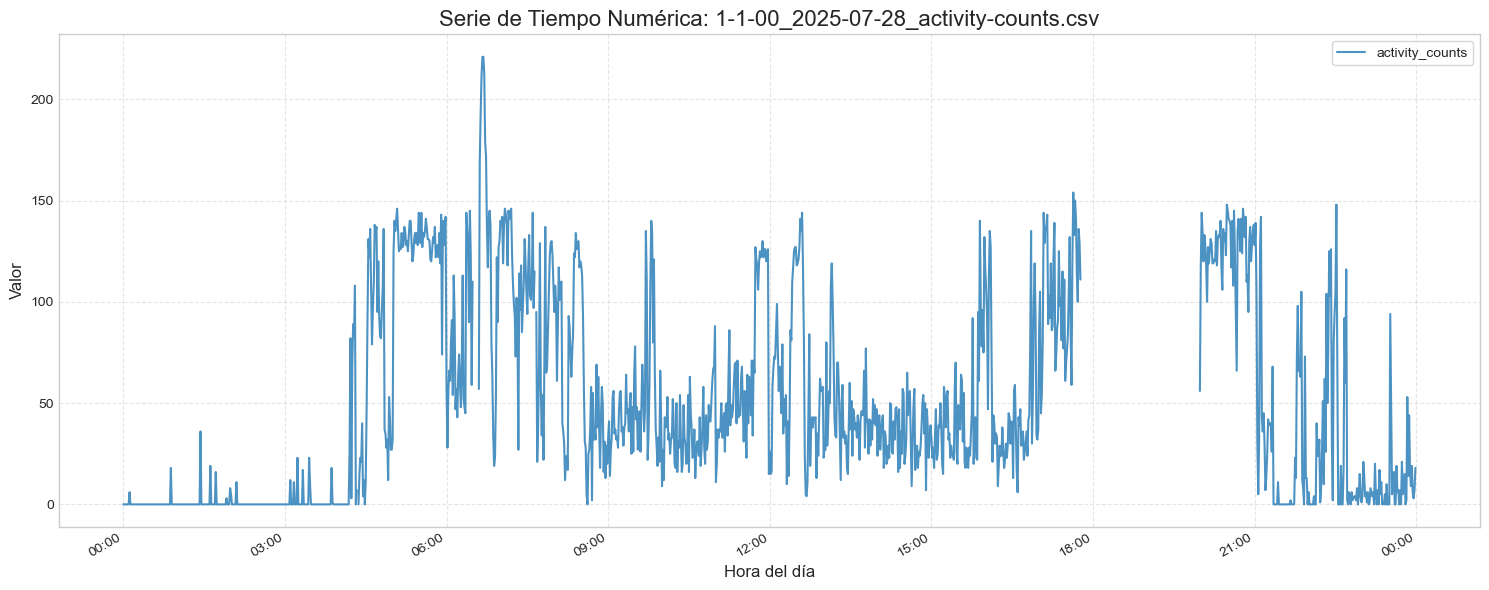


--------------------------------------------------------------------------------



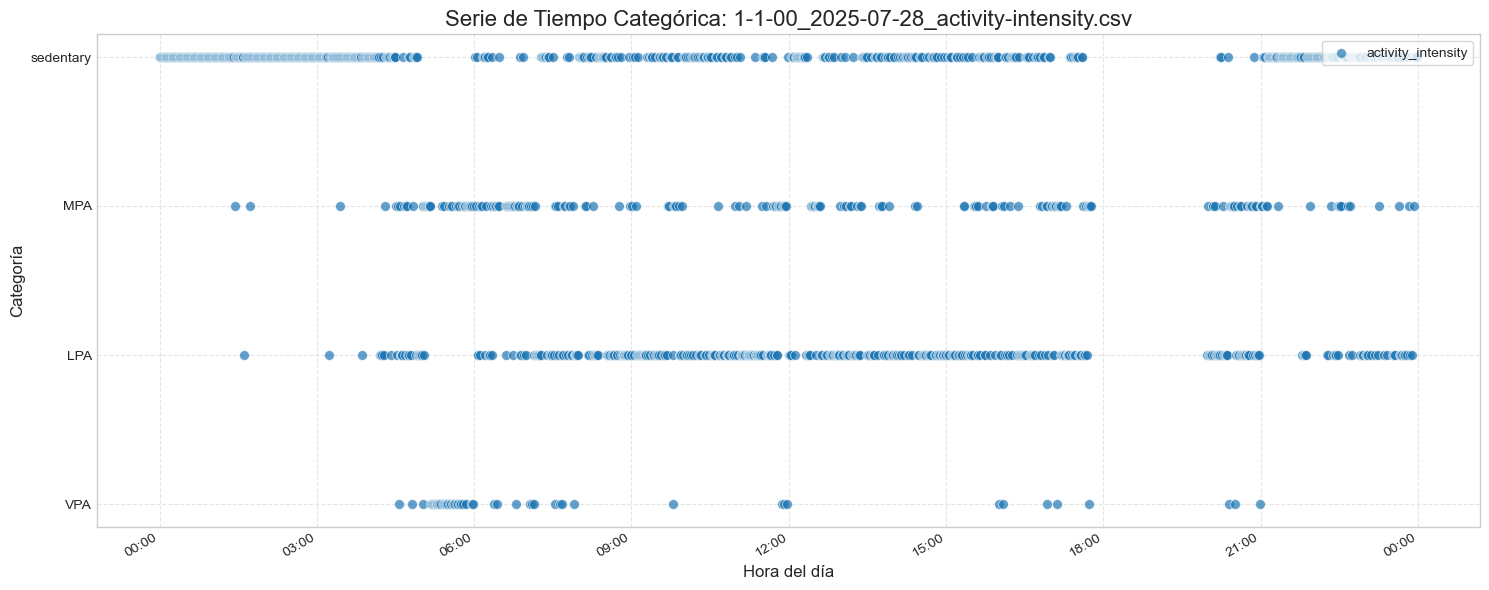


--------------------------------------------------------------------------------



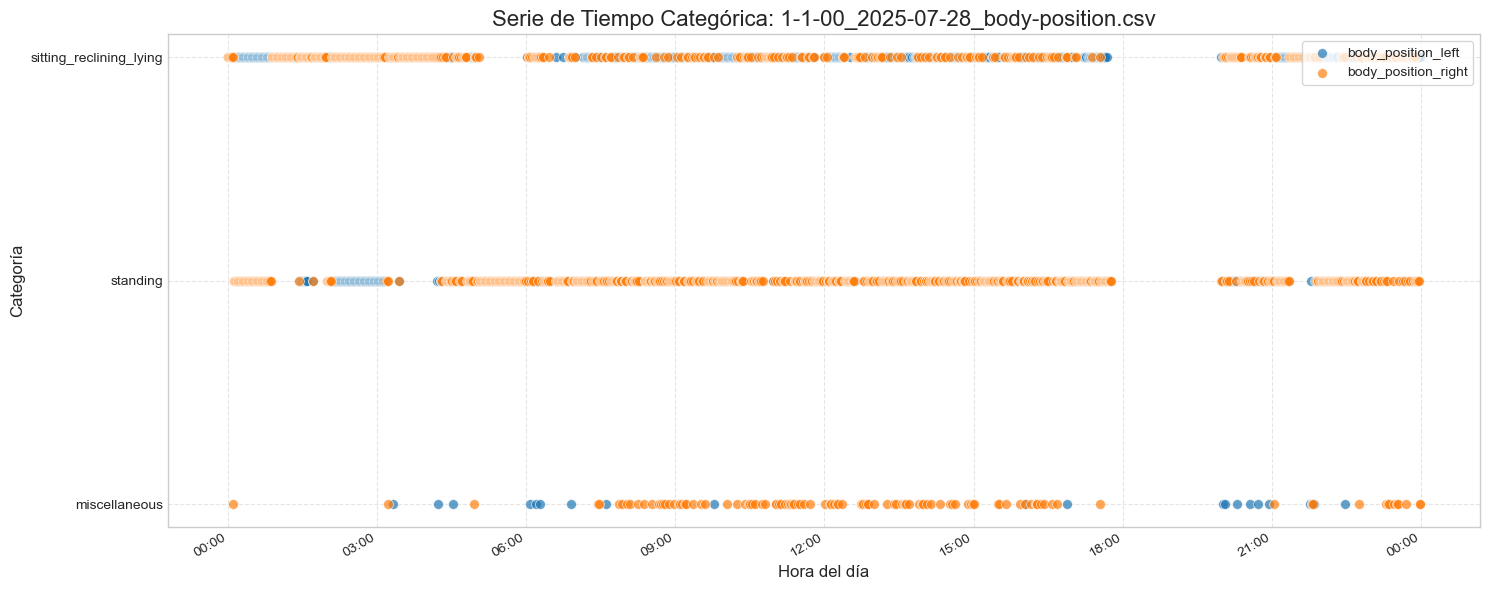


--------------------------------------------------------------------------------



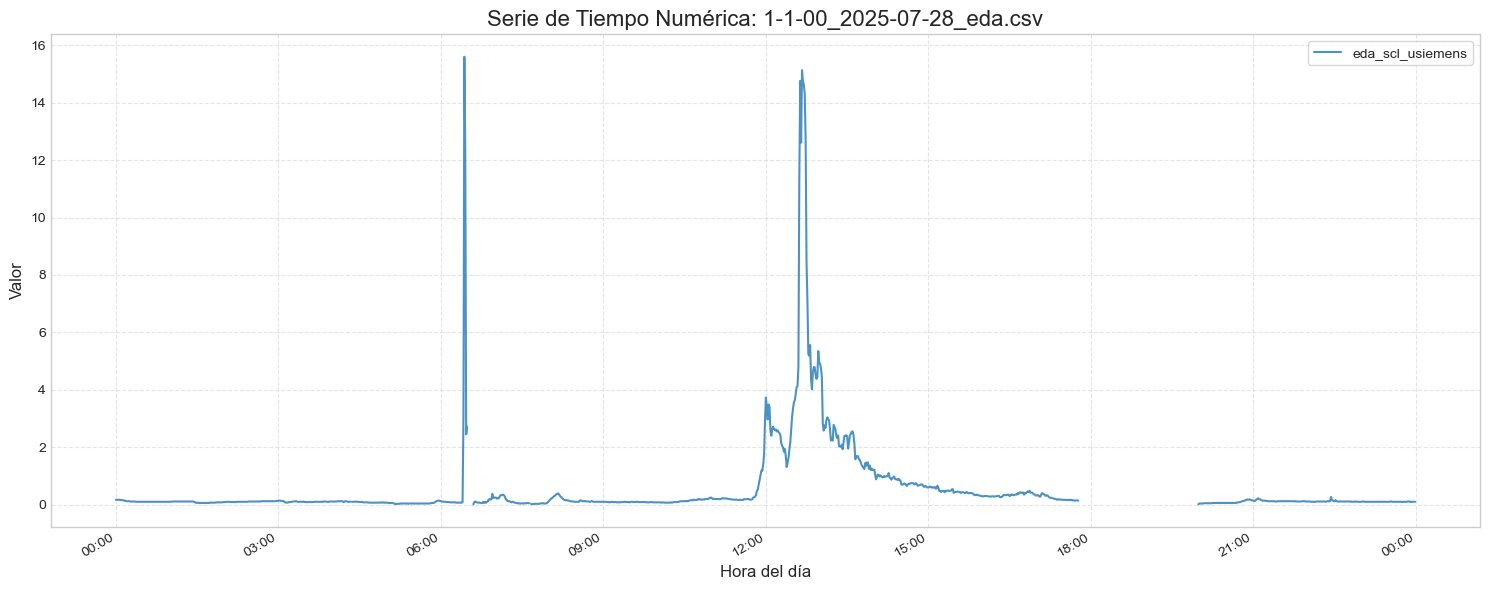


--------------------------------------------------------------------------------



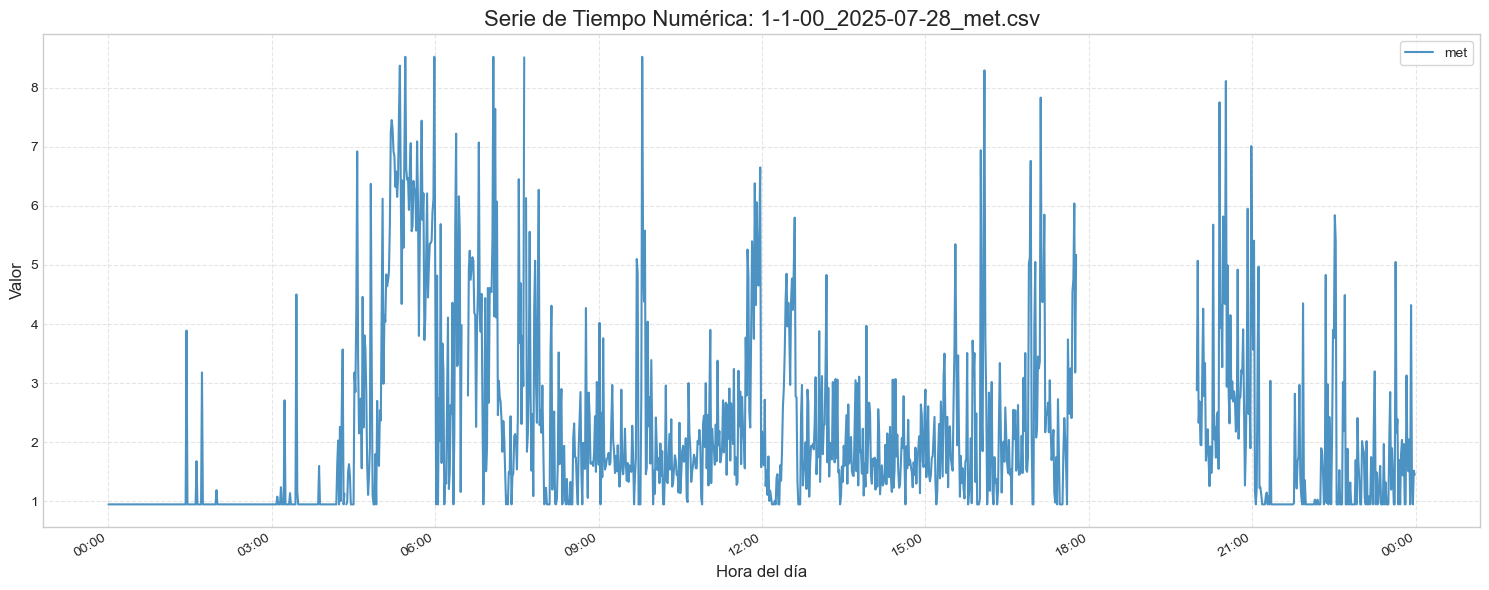


--------------------------------------------------------------------------------



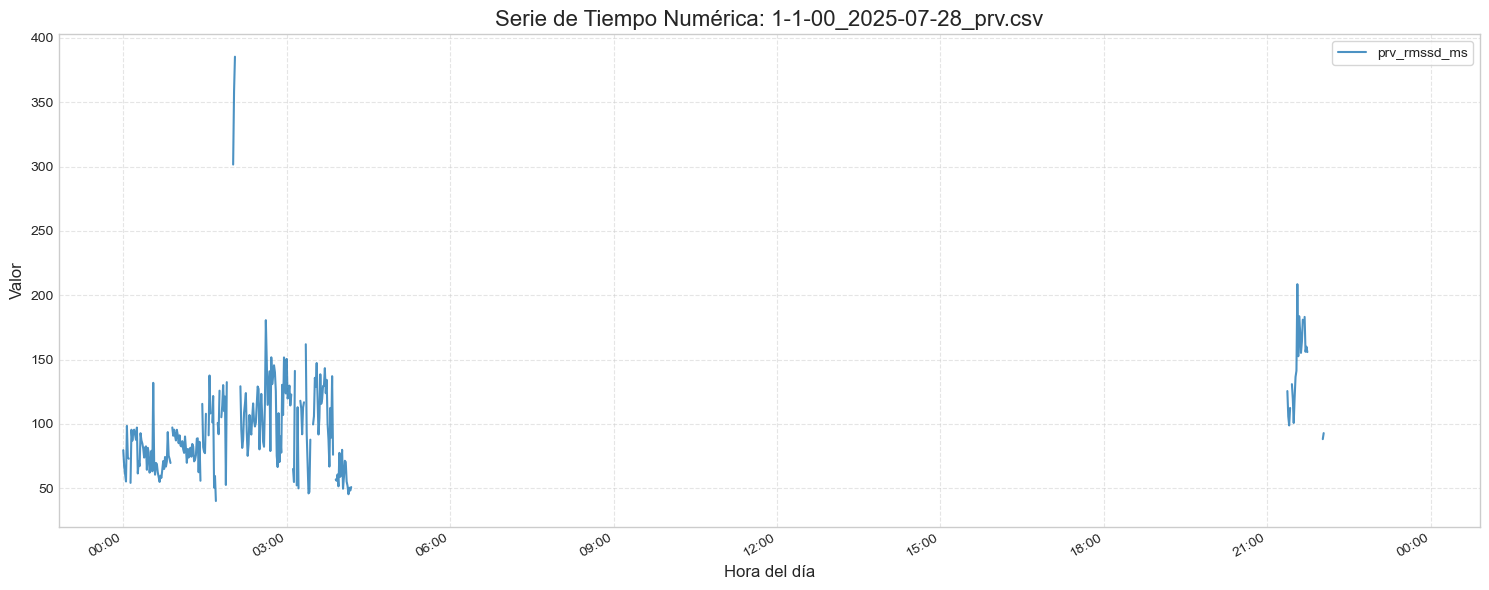


--------------------------------------------------------------------------------



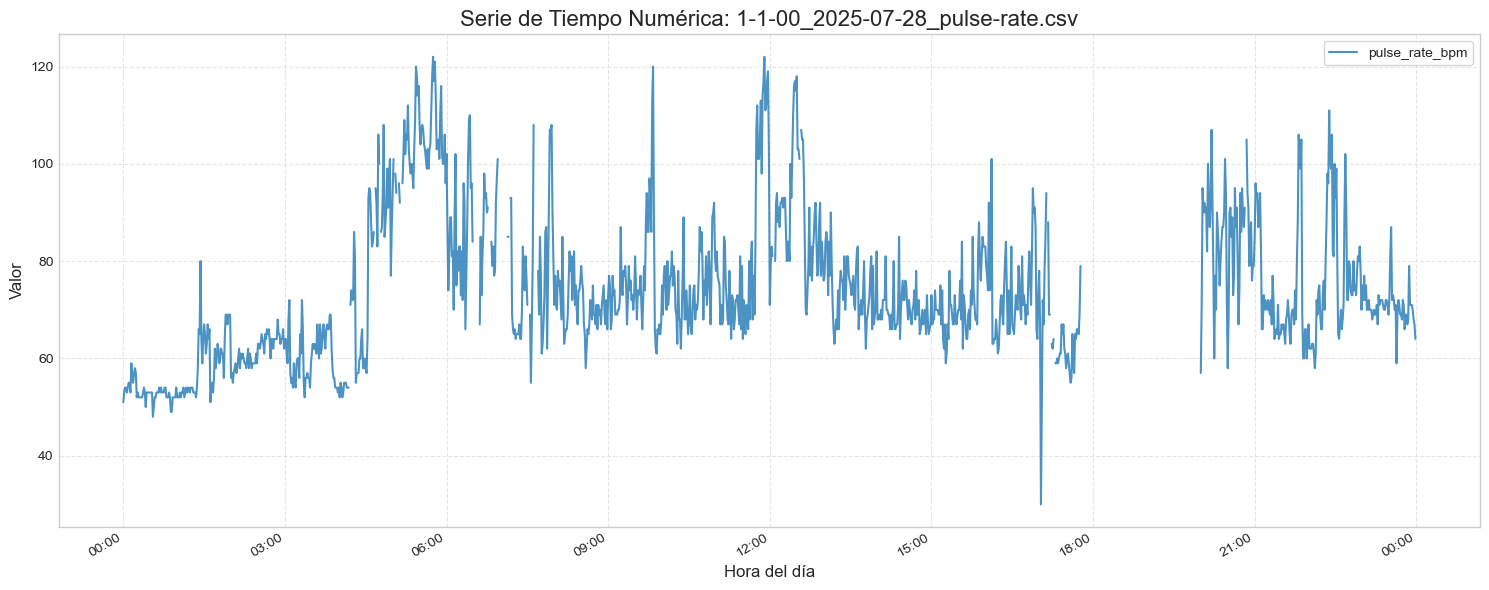


--------------------------------------------------------------------------------



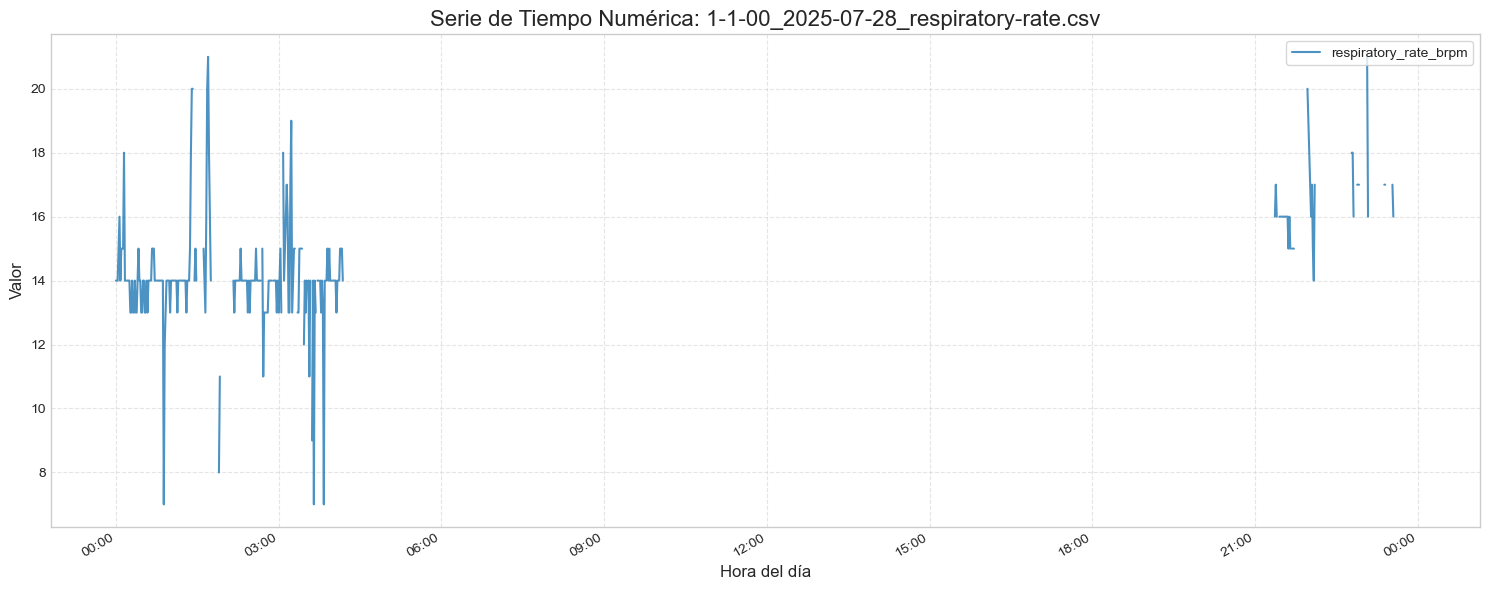


--------------------------------------------------------------------------------



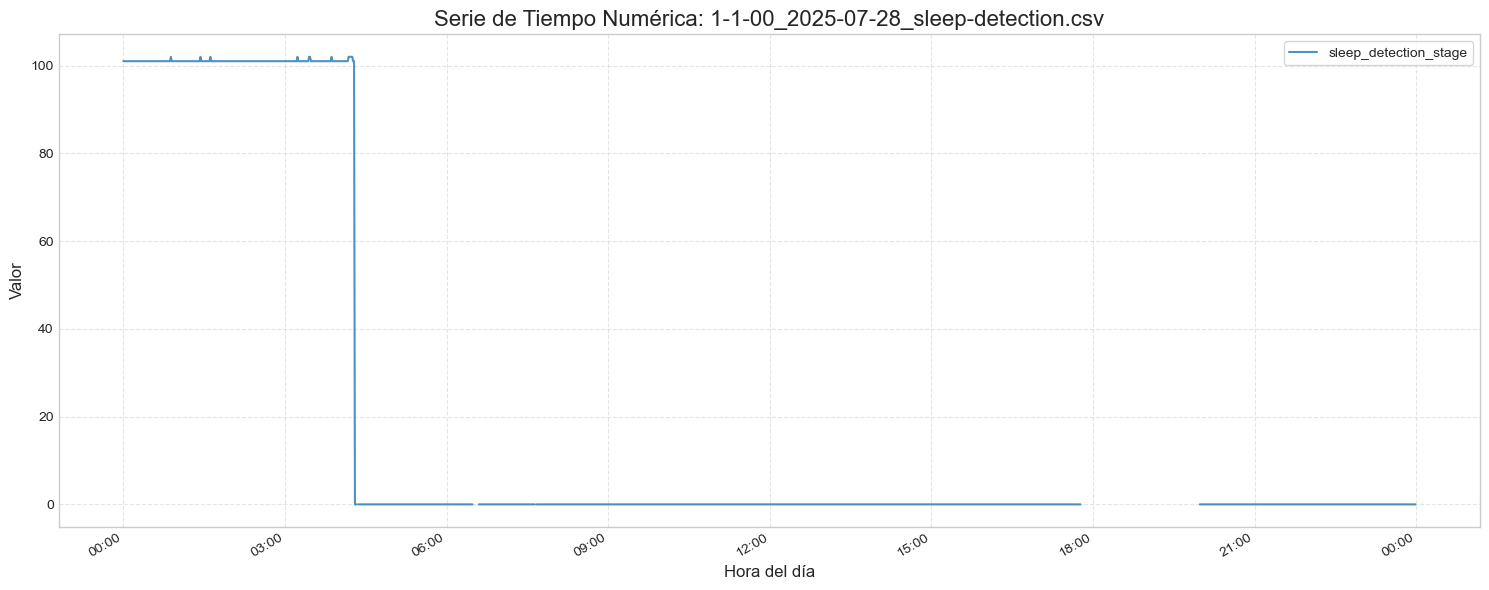


--------------------------------------------------------------------------------



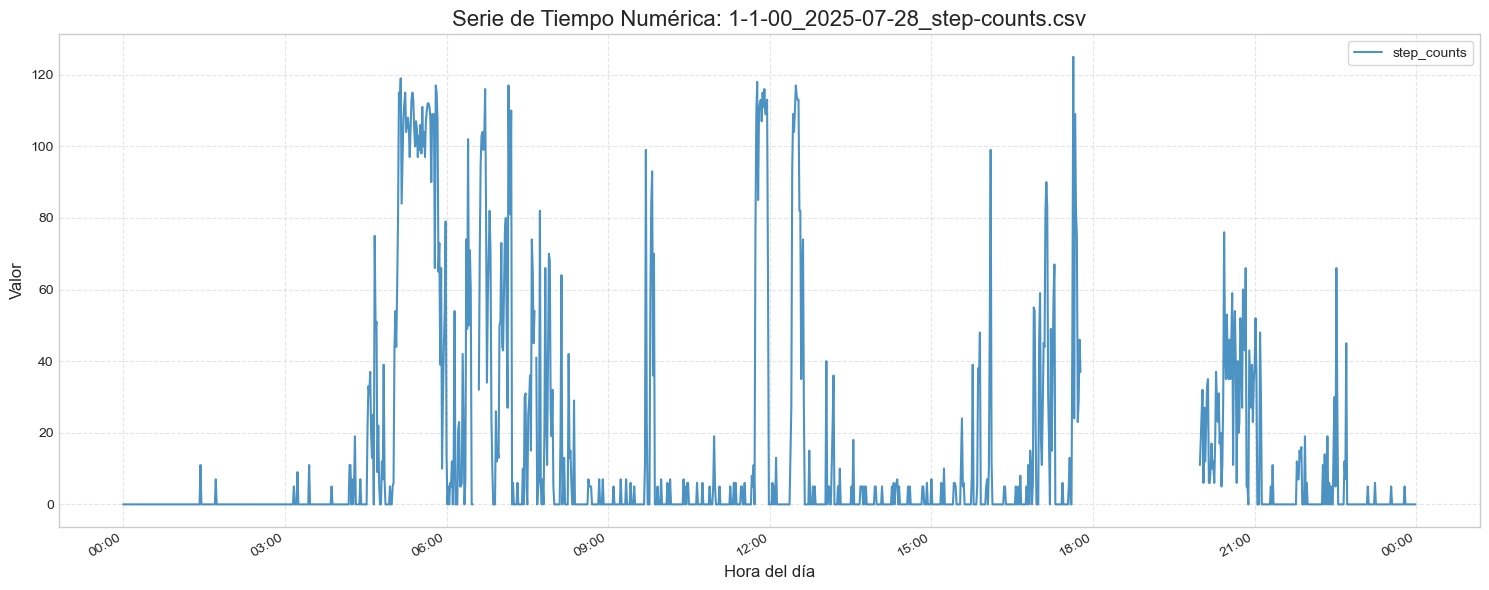


--------------------------------------------------------------------------------



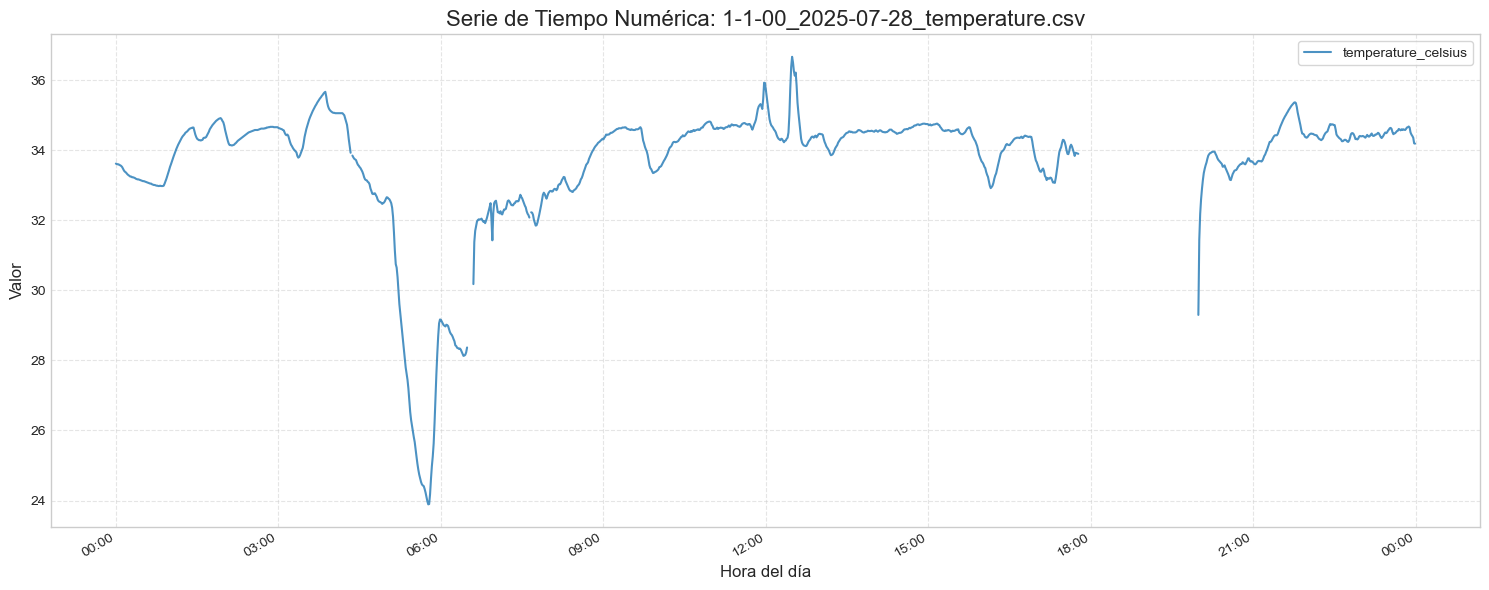


--------------------------------------------------------------------------------



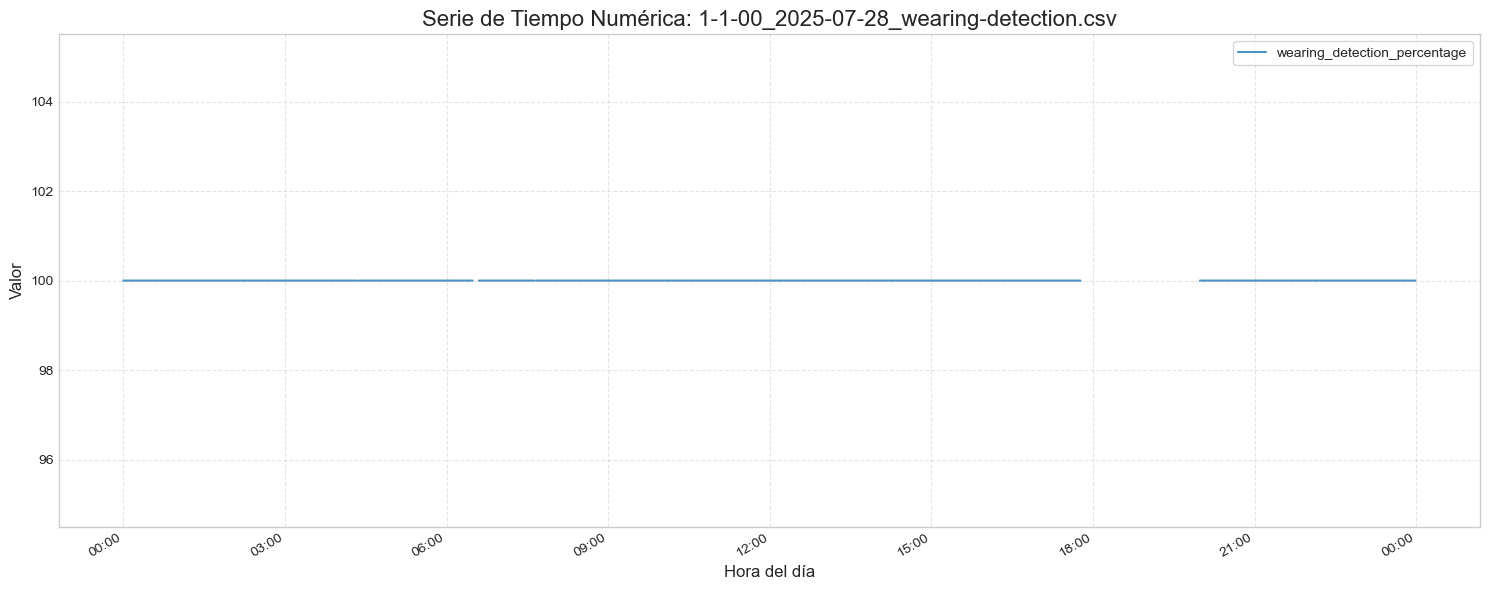


--------------------------------------------------------------------------------



In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
import seaborn as sns
from IPython.display import display

# Intentar configurar un estilo visual agradable
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')

folder_path = '.'  # Ahora el directorio actual
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Columnas que son metadatos y NO deben graficarse
metadata_cols = ['timestamp_unix', 'timestamp_iso', 'participant_full_id', 'missing_value_reason']

print(f"Generando gráficos temporales para {len(files)} archivos...\n")

for file in files:
    file_path = os.path.join(folder_path, file)
    try:
        # Leer el archivo con autodetección de separador
        try:
            df = pd.read_csv(file_path, sep=';')
            if df.shape[1] == 1:
                df = pd.read_csv(file_path, sep=',')
        except Exception:
            df = pd.read_csv(file_path, sep=',')
        
        # Convertir timestamp_iso a objetos datetime para el eje X
        if 'timestamp_iso' in df.columns:
            df['datetime'] = pd.to_datetime(df['timestamp_iso'])
            df = df.set_index('datetime')
        
        # Identificar columnas relevantes (excluyendo metadatos)
        data_cols = [c for c in df.columns if c not in metadata_cols]
        
        # Filtrar columnas numéricas y categóricas
        numeric_cols = df[data_cols].select_dtypes(include=['number']).columns
        categorical_cols = df[data_cols].select_dtypes(include=['object', 'category']).columns
        
        if len(numeric_cols) > 0:
            # --- Graficar datos numéricos (como antes) ---
            fig, ax = plt.subplots(figsize=(15, 6))
            for col in numeric_cols:
                ax.plot(df.index, df[col], label=col, linewidth=1.5, alpha=0.8)
            
            ax.set_title(f"Serie de Tiempo Numérica: {file}", fontsize=16)
            ax.set_ylabel("Valor", fontsize=12)
            ax.legend(loc='upper right', frameon=True)
            ax.set_xlabel("Hora del día", fontsize=12)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            fig.autofmt_xdate()
            ax.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            display(fig)
            plt.close(fig)

        elif len(categorical_cols) > 0:
            # --- Graficar datos categóricos ---
            fig, ax = plt.subplots(figsize=(15, 6))
            for col in categorical_cols:
                sns.scatterplot(x=df.index, y=df[col], label=col, s=50, alpha=0.7, ax=ax)

            ax.set_title(f"Serie de Tiempo Categórica: {file}", fontsize=16)
            ax.set_ylabel("Categoría", fontsize=12)
            ax.legend(loc='upper right', frameon=True)
            ax.set_xlabel("Hora del día", fontsize=12)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            fig.autofmt_xdate()
            ax.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            display(fig)
            plt.close(fig)
            
        else:
            print(f"Saltando {file}: No se encontraron columnas numéricas ni categóricas para graficar.")
            continue

        print("\n" + "-"*80 + "\n")
        
    except Exception as e:
        print(f"Error graficando {file}: {e}")